# Desafio Final — Análise de Transações ClearBank (Fase 3)

Você é analista de dados júnior na fintech **ClearBank**. Recebeu um arquivo
`transacoes.csv` com dados de transações — incluindo registros "sujos"
(IDs não numéricos, datas mal formatadas, valores inválidos etc.). Sua
missão é ler, **validar e limpar** os dados, calcular **métricas mensais**,
sinalizar **transações suspeitas** (acima de R$ 10.000,00), exibir um
relatório formatado no terminal e exportar um `relatorio.json`.

## Como executar

1. Garanta que `transacoes.csv` está na mesma pasta do notebook.
2. Menu **Run → Run All Cells** (Jupyter) ou **Ambiente de execução → Executar tudo** (Colab).
3. As células opcionais (RO1/RO2) exigem `pandas` e `matplotlib`:
   `pip install pandas matplotlib`.

## Requisitos atendidos

- ✅ Leitura de CSV com `csv.DictReader` (stdlib).
- ✅ 6+ funções com responsabilidades separadas.
- ✅ 3 usos distintos de `try/except` (específicos).
- ✅ Datas via `datetime.strptime` / `strftime`.
- ✅ Métricas mensais (qtd, crédito, débito, saldo, média, maior, menor).
- ✅ Detecção de suspeitas (`LIMITE_SUSPEITO = 10000.00`).
- ✅ Exportação `relatorio.json` (`ensure_ascii=False, indent=2`).
- ✅ Relatório formatado no terminal (padrão BR).
- ✅ **RO1** análise alternativa com pandas.
- ✅ **RO2** gráfico com matplotlib (`grafico.png`).

## Célula 2 — Imports e constantes globais

In [16]:
import csv
import json
from datetime import datetime
from collections import defaultdict

ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
LIMITE_SUSPEITO = 10000.00
FORMATO_DATA = "%Y-%m-%d"
TIPOS_VALIDOS = {"credito", "debito"}

## Célula 3 — `ler_transacoes(caminho)`

Lê o CSV com `csv.DictReader`. Usa `try/except FileNotFoundError` (1º uso de
tratamento de erro): se o arquivo não existir, avisa e retorna lista vazia.
Retorna a lista de dicionários crus, **sem validar** ainda.

In [17]:
def ler_transacoes(caminho):
    """Lê o CSV e retorna a lista de linhas cruas (dicts)."""
    try:
        with open(caminho, newline="", encoding="utf-8") as arq:
            return list(csv.DictReader(arq))
    except FileNotFoundError:
        print(f"[ERRO] Arquivo não encontrado: {caminho}")
        return []


# Teste rápido
_brutas = ler_transacoes(ARQUIVO_CSV)
print(f"Linhas lidas: {len(_brutas)}")
print("Primeira linha:", _brutas[0] if _brutas else "(vazio)")

Linhas lidas: 20
Primeira linha: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'C001', 'tipo': 'credito', 'valor': '1500.00', 'descricao': 'Deposito salario', 'categoria': 'renda'}


## Célula 4 — Funções de validação

- `validar_data` usa `datetime.strptime` com `try/except ValueError` (2º uso).
- `validar_valor` usa `float()` com `try/except ValueError` (3º uso) e rejeita ≤ 0.
- `validar_transacao` aplica **todas** as regras e devolve um dict limpo (com a
  data já como `datetime`) ou `None` se a linha for inválida.

In [18]:
def validar_data(texto):
    """Converte texto em datetime ou retorna None se inválido."""
    try:
        return datetime.strptime(texto.strip(), FORMATO_DATA)
    except ValueError:
        return None


def validar_valor(texto):
    """Converte texto em float positivo ou retorna None."""
    try:
        valor = float(texto)
    except ValueError:
        return None
    return valor if valor > 0 else None


def validar_transacao(linha):
    """Valida uma linha crua. Retorna dict limpo ou None."""
    if not linha.get("id", "").strip().isdigit():
        return None
    if not linha.get("cliente_id", "").strip():
        return None
    data = validar_data(linha.get("data", ""))
    if data is None:
        return None
    tipo = linha.get("tipo", "").strip().lower()
    if tipo not in TIPOS_VALIDOS:
        return None
    valor = validar_valor(linha.get("valor", ""))
    if valor is None:
        return None
    return {
        "id": int(linha["id"]),
        "data": data,
        "cliente_id": linha["cliente_id"].strip(),
        "tipo": tipo,
        "valor": valor,
        "descricao": linha.get("descricao", "").strip(),
        "categoria": linha.get("categoria", "").strip(),
    }


# Teste rápido: 1 válida + 2 inválidas
_amostra = [
    {"id": "1", "data": "2026-01-05", "cliente_id": "C001", "tipo": "credito",
     "valor": "1500.00", "descricao": "ok", "categoria": "renda"},
    {"id": "abc", "data": "2026-01-05", "cliente_id": "C001", "tipo": "credito",
     "valor": "100", "descricao": "id ruim", "categoria": "x"},
    {"id": "2", "data": "2026/02/30", "cliente_id": "C002", "tipo": "debito",
     "valor": "50", "descricao": "data ruim", "categoria": "x"},
]
for _l in _amostra:
    print(validar_transacao(_l))

{'id': 1, 'data': datetime.datetime(2026, 1, 5, 0, 0), 'cliente_id': 'C001', 'tipo': 'credito', 'valor': 1500.0, 'descricao': 'ok', 'categoria': 'renda'}
None
None


## Célula 5 — `processar_transacoes(linhas_brutas)`

Itera sobre as linhas cruas, chama `validar_transacao` e separa em válidas e
inválidas. Retorna `(validas, total_lidas, total_invalidas)`.

In [19]:
def processar_transacoes(linhas_brutas):
    """Separa linhas válidas das inválidas."""
    validas = []
    invalidas = 0
    for linha in linhas_brutas:
        transacao = validar_transacao(linha)
        if transacao is None:
            invalidas += 1
        else:
            validas.append(transacao)
    return validas, len(linhas_brutas), invalidas


# Teste rápido
_validas, _total, _inval = processar_transacoes(_brutas)
print(f"Lidas: {_total} | Válidas: {len(_validas)} | Inválidas: {_inval}")

Lidas: 20 | Válidas: 15 | Inválidas: 5


## Célula 6 — `gerar_relatorio(validas)`

Calcula o período (data mais antiga, mais recente e dias entre elas), agrupa
por mês com `defaultdict` e calcula por mês: quantidade, total de crédito,
total de débito, saldo, média, maior e menor transação. Filtra as suspeitas
(`valor > LIMITE_SUSPEITO`).

In [20]:
def gerar_relatorio(validas):
    """Monta o dicionário de relatório a partir das transações válidas."""
    datas = [t["data"] for t in validas]
    mais_antiga = min(datas)
    mais_recente = max(datas)
    dias_periodo = (mais_recente - mais_antiga).days

    por_mes = defaultdict(list)
    for t in validas:
        por_mes[t["data"].strftime("%Y-%m")].append(t)

    resumo_mensal = {}
    for mes in sorted(por_mes):
        trans = por_mes[mes]
        total_credito = sum(t["valor"] for t in trans if t["tipo"] == "credito")
        total_debito = sum(t["valor"] for t in trans if t["tipo"] == "debito")
        maior = max(trans, key=lambda t: t["valor"])
        menor = min(trans, key=lambda t: t["valor"])
        resumo_mensal[mes] = {
            "quantidade": len(trans),
            "total_credito": round(total_credito, 2),
            "total_debito": round(total_debito, 2),
            "saldo": round(total_credito - total_debito, 2),
            "media": round(sum(t["valor"] for t in trans) / len(trans), 2),
            "maior_valor": {"id": maior["id"], "valor": maior["valor"],
                            "descricao": maior["descricao"]},
            "menor_valor": {"id": menor["id"], "valor": menor["valor"],
                            "descricao": menor["descricao"]},
        }

    suspeitas = [
        {"id": t["id"], "data": t["data"].strftime(FORMATO_DATA),
         "cliente_id": t["cliente_id"], "tipo": t["tipo"],
         "valor": t["valor"], "descricao": t["descricao"]}
        for t in validas if t["valor"] > LIMITE_SUSPEITO
    ]

    return {
        "gerado_em": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "periodo": {"mais_antiga": mais_antiga.strftime(FORMATO_DATA),
                    "mais_recente": mais_recente.strftime(FORMATO_DATA)},
        "dias_periodo": dias_periodo,
        "total_transacoes_validas": len(validas),
        "resumo_mensal": resumo_mensal,
        "suspeitas": suspeitas,
    }


# Teste rápido
_rel = gerar_relatorio(_validas)
print("Meses:", list(_rel["resumo_mensal"].keys()))
print("Suspeitas:", len(_rel["suspeitas"]))

Meses: ['2026-01', '2026-02', '2026-03', '2026-04']
Suspeitas: 2


## Célula 7 — Utilitário de formato (padrão brasileiro)

Converte um número para o formato monetário BR (`R$ 1.234,56`) usando a
técnica do `replace` triplo sugerida nas dicas do desafio.

In [21]:
def formatar_brl(valor):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


# Teste rápido
print(formatar_brl(1234567.8))
print(formatar_brl(-299.99))

R$ 1.234.567,80
R$ -299,99


## Célula 8 — `salvar_json(relatorio, caminho)`

Serializa o relatório para JSON com `ensure_ascii=False` (preserva acentos) e
`indent=2`. O `default=str` garante a serialização de qualquer objeto de data
remanescente.

In [22]:
def salvar_json(relatorio, caminho):
    """Grava o relatório em disco como JSON formatado."""
    with open(caminho, "w", encoding="utf-8") as arq:
        json.dump(relatorio, arq, ensure_ascii=False, indent=2, default=str)
    print(f"Relatório salvo em: {caminho}")

## Célula 9 — `exibir_relatorio(relatorio)`

Imprime o relatório formatado no terminal: cabeçalho com separadores, período,
contagem de válidas/inválidas, bloco por mês e a lista de transações suspeitas.

In [23]:
def exibir_relatorio(relatorio):
    """Imprime o relatório formatado no terminal."""
    print("=" * 50)
    print("        RELATÓRIO DE TRANSAÇÕES - CLEARBANK")
    print("=" * 50)
    p = relatorio["periodo"]
    print(f"Período: {p['mais_antiga']} até {p['mais_recente']} "
          f"({relatorio['dias_periodo']} dias)")
    print(f"Transações válidas:   {relatorio['total_transacoes_validas']}")
    print(f"Transações inválidas: {relatorio.get('total_transacoes_invalidas', 0)}")
    print("=" * 50)
    for mes, r in relatorio["resumo_mensal"].items():
        print(f"\n--- {mes} ---")
        print(f"  Quantidade:    {r['quantidade']}")
        print(f"  Total crédito: {formatar_brl(r['total_credito'])}")
        print(f"  Total débito:  {formatar_brl(r['total_debito'])}")
        print(f"  Saldo:         {formatar_brl(r['saldo'])}")
        print(f"  Média:         {formatar_brl(r['media'])}")
        print(f"  Maior valor:   {formatar_brl(r['maior_valor']['valor'])} "
              f"(id {r['maior_valor']['id']} - {r['maior_valor']['descricao']})")
        print(f"  Menor valor:   {formatar_brl(r['menor_valor']['valor'])} "
              f"(id {r['menor_valor']['id']} - {r['menor_valor']['descricao']})")
    print("\n" + "=" * 50)
    print("        TRANSAÇÕES SUSPEITAS (> R$ 10.000,00)")
    print("=" * 50)
    if not relatorio["suspeitas"]:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for s in relatorio["suspeitas"]:
            print(f"  [id {s['id']}] {s['data']} - {s['cliente_id']} - "
                  f"{formatar_brl(s['valor'])} - {s['descricao']}")

## Célula 10 — Execução principal

Orquestra o fluxo completo: lê → processa → gera relatório → salva JSON → exibe.

In [24]:
brutas = ler_transacoes(ARQUIVO_CSV)
validas, total_lidas, total_invalidas = processar_transacoes(brutas)
print(f"Total de linhas lidas: {total_lidas}")
print(f"Linhas válidas: {len(validas)}")
print(f"Linhas inválidas: {total_invalidas}")
print()

relatorio = gerar_relatorio(validas)
relatorio["total_transacoes_invalidas"] = total_invalidas
salvar_json(relatorio, ARQUIVO_JSON)
print()
exibir_relatorio(relatorio)

Total de linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5

Relatório salvo em: relatorio.json

        RELATÓRIO DE TRANSAÇÕES - CLEARBANK
Período: 2026-01-05 até 2026-04-25 (110 dias)
Transações válidas:   15
Transações inválidas: 5

--- 2026-01 ---
  Quantidade:    4
  Total crédito: R$ 13.500,00
  Total débito:  R$ 340,65
  Saldo:         R$ 13.159,35
  Média:         R$ 3.460,16
  Maior valor:   R$ 12.000,00 (id 4 - Transferencia recebida)
  Menor valor:   R$ 89,90 (id 3 - Conta de luz)

--- 2026-02 ---
  Quantidade:    4
  Total crédito: R$ 3.200,50
  Total débito:  R$ 17.380,20
  Saldo:         R$ -14.179,70
  Média:         R$ 5.145,18
  Maior valor:   R$ 15.750,00 (id 7 - Compra de equipamentos)
  Menor valor:   R$ 430,20 (id 8 - Posto de gasolina)

--- 2026-03 ---
  Quantidade:    4
  Total crédito: R$ 2.300,00
  Total débito:  R$ 2.599,99
  Saldo:         R$ -299,99
  Média:         R$ 1.225,00
  Maior valor:   R$ 2.500,00 (id 11 - Reforma cozinha)
  Menor valor:   R$ 

## Célula 11 — RO1: Análise alternativa com pandas

Requisito opcional 1. Reproduzimos a análise mensal usando **pandas** e
comparamos os saldos com a solução nativa — eles devem ser **idênticos**.
A lógica completa também está em `analise_pandas.py` (executável via CLI).

> Requer `pandas`: `pip install pandas`.

In [25]:
import pandas as pd

df = pd.read_csv(ARQUIVO_CSV, dtype=str)

# Conversões com coerção: inválidos viram NaN/NaT.
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["data"] = pd.to_datetime(df["data"], format=FORMATO_DATA, errors="coerce")
df["cliente_id"] = df["cliente_id"].str.strip()
df.loc[df["cliente_id"] == "", "cliente_id"] = pd.NA
df["tipo"] = df["tipo"].str.strip().str.lower()

# Filtro de validade equivalente ao validar_transacao() nativo.
valido = (
    df["id"].notna()
    & df["data"].notna()
    & df["cliente_id"].notna()
    & df["valor"].notna()
    & (df["valor"] > 0)
    & df["tipo"].isin(TIPOS_VALIDOS)
)
df_validas = df[valido].copy()
df_validas["mes"] = df_validas["data"].dt.strftime("%Y-%m")
print(f"Transações válidas (pandas): {len(df_validas)}")

creditos = (df_validas[df_validas["tipo"] == "credito"]
            .groupby("mes")["valor"].sum().rename("total_credito"))
debitos = (df_validas[df_validas["tipo"] == "debito"]
           .groupby("mes")["valor"].sum().rename("total_debito"))
resumo = df_validas.groupby("mes").agg(
    quantidade=("valor", "size"), media=("valor", "mean")
).join(creditos).join(debitos).fillna(0.0)
resumo["saldo"] = resumo["total_credito"] - resumo["total_debito"]
resumo = resumo[["quantidade", "total_credito", "total_debito", "saldo", "media"]]

print("\n=== RESUMO MENSAL (pandas) ===")
print(resumo.to_string(float_format=lambda x: f"{x:,.2f}"))

# Conferência: saldos pandas == saldos nativos
iguais = all(
    round(resumo.loc[mes, "saldo"], 2) == relatorio["resumo_mensal"][mes]["saldo"]
    for mes in resumo.index
)
print(f"\nSaldos idênticos à solução nativa? {iguais}")

Transações válidas (pandas): 15

=== RESUMO MENSAL (pandas) ===
         quantidade  total_credito  total_debito      saldo    media
mes                                                                 
2026-01           4      13,500.00        340.65  13,159.35 3,460.16
2026-02           4       3,200.50     17,380.20 -14,179.70 5,145.18
2026-03           4       2,300.00      2,599.99    -299.99 1,225.00
2026-04           3       5,400.00      1,960.45   3,439.55 2,453.48

Saldos idênticos à solução nativa? True


## Célula 13 — RO2: Gráfico com matplotlib

Requisito opcional 2. Gráfico de **barras empilhadas de crédito vs débito por
mês**, salvo como `grafico.png`.

> Requer `matplotlib`: `pip install matplotlib`.

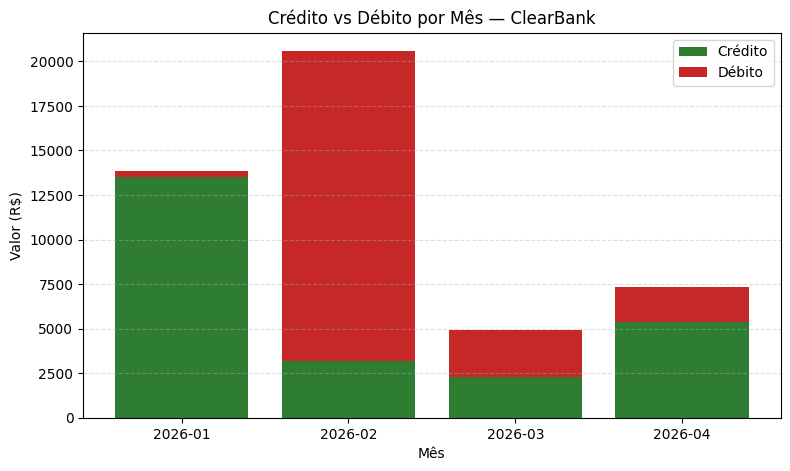

Gráfico salvo em: grafico.png


In [26]:
import matplotlib.pyplot as plt

meses = list(relatorio["resumo_mensal"].keys())
creditos_mes = [relatorio["resumo_mensal"][m]["total_credito"] for m in meses]
debitos_mes = [relatorio["resumo_mensal"][m]["total_debito"] for m in meses]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(meses, creditos_mes, label="Crédito", color="#2e7d32")
ax.bar(meses, debitos_mes, bottom=creditos_mes, label="Débito", color="#c62828")

ax.set_title("Crédito vs Débito por Mês — ClearBank")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor (R$)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("grafico.png", bbox_inches="tight", dpi=120)
plt.show()
print("Gráfico salvo em: grafico.png")